# Arab Light crude-oil TGA: revised machine-learning analysis

This notebook reproduces the final ML results used in the manuscript and Supplementary Information.

**Analysis principles**
- Nitrogen and air are modelled separately.
- The response is remaining mass percentage.
- The primary evaluation withholds one complete heating-rate curve at a time.
- RF and GBR configurations are **prespecified fixed settings**. Sensitivity analyses are post-hoc robustness checks and are not used to tune the final holdout results.
- The random row split is reported only as a reconstruction benchmark.
- The labels *intermediate-rate*, *upper-bound*, and *lower-bound holdout* are used instead of claiming continuous tree-model extrapolation.
- A temperature-only versus temperature-plus-heating-rate ablation is included.
- Cross-atmosphere and virtual 15 °C min⁻¹ analyses are excluded from the publication workflow.

## 1. Software, data, and reproducibility

In [1]:
import os, sys, copy, platform, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn, scipy, matplotlib
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

RANDOM_STATE = 42
DATA_PATH = 'arab_light_TGA_cleaned_ML_ready_v2.xlsx'
OUTDIR = 'Arab_Light_TGA_ML_REVISED_outputs'
os.makedirs(OUTDIR, exist_ok=True)

print('Python:', platform.python_version())
print('NumPy:', np.__version__)
print('pandas:', pd.__version__)
print('scikit-learn:', sklearn.__version__)
print('SciPy:', scipy.__version__)
print('Matplotlib:', matplotlib.__version__)
print('Random seed:', RANDOM_STATE)

Python: 3.13.5
NumPy: 2.3.5
pandas: 2.2.3
scikit-learn: 1.8.0
SciPy: 1.17.0
Matplotlib: 3.10.8
Random seed: 42


### Preprocessing provenance

The supplied ML workbook already contains the cleaned curves. Its documented cleaning chain was:

1. preserve experimental time order and remove small backward temperature jitter by cumulative maximum;
2. interpolate each curve from 323 to 1000 K on a uniform 1 K grid;
3. correct terminal baseline drift for air curves while retaining genuine low-temperature oxygen uptake;
4. apply Savitzky-Golay smoothing (window 21, polynomial order 3) and recompute DTG;
5. enforce monotonic non-increasing mass under N₂ using isotonic regression, without constraining air curves;
6. recalculate true fractional conversion, α = (m₀ − mₜ)/(m₀ − m_f).

The supplied dataset contains one measured curve for each atmosphere-heating-rate condition. Replicate curves, if performed experimentally, were not included; therefore, experimental repeatability uncertainty is not propagated into the ML metrics.

In [2]:
df_full = pd.read_excel(DATA_PATH, sheet_name='ML_Master')
required = {'curve_id','atmosphere','beta','temp_K','temp_C','mass_pct','alpha'}
missing = required.difference(df_full.columns)
if missing:
    raise ValueError(f'Missing columns: {sorted(missing)}')

df = df_full[['curve_id','atmosphere','beta','temp_K','temp_C','mass_pct','alpha']].copy()
FEATURES = ['temp_K','beta']
TARGET = 'mass_pct'
ATMOSPHERES = ['N2','Air']
MODEL_NAMES = ['RF','GBR','SVR','MLR','PLSR']
LORO_CASES = [
    ('N2',[5,20],10,'Intermediate-rate holdout'),
    ('N2',[5,10],20,'Upper-bound holdout'),
    ('N2',[10,20],5,'Lower-bound holdout'),
    ('Air',[5,20],10,'Intermediate-rate holdout'),
    ('Air',[5,10],20,'Upper-bound holdout'),
    ('Air',[10,20],5,'Lower-bound holdout'),
]
print('Dataset shape:', df.shape)
print(df.groupby(['atmosphere','beta']).size())

Dataset shape: (4068, 7)
atmosphere  beta
Air         5       678
            10      678
            20      678
N2          5       678
            10      678
            20      678
dtype: int64


## 2. Prespecified model configurations

In [3]:
def make_models(feature_count=2):
    return {
        'RF': (RandomForestRegressor(n_estimators=100, max_depth=10,
                                     random_state=RANDOM_STATE, n_jobs=-1), False),
        'GBR': (GradientBoostingRegressor(n_estimators=100, max_depth=4,
                                          learning_rate=0.1,
                                          random_state=RANDOM_STATE), False),
        'SVR': (SVR(kernel='rbf', C=10, gamma=0.01, epsilon=0.01), True),
        'MLR': (LinearRegression(), False),
        'PLSR': (PLSRegression(n_components=min(2, feature_count), scale=True), False),
    }

def fit_predict(model, X_train, y_train, X_test, scale=False):
    if scale:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
    model.fit(X_train, y_train)
    return np.ravel(model.predict(X_test))

def score(y_true, y_pred):
    return {
        'R2': r2_score(y_true, y_pred),
        'RMSEP': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
    }

def get_subset(atmosphere, betas, features):
    sub = df[(df.atmosphere == atmosphere) & df.beta.isin(betas)].sort_values(['beta','temp_K']).copy()
    return sub, sub[features].values, sub[TARGET].values

pd.DataFrame([
    ['RF','100 trees; maximum depth 10','Prespecified'],
    ['GBR','100 estimators; maximum depth 4; learning rate 0.1','Prespecified'],
    ['SVR','RBF; C=10; gamma=0.01; epsilon=0.01','Fixed, not exhaustively optimized'],
    ['MLR','Ordinary least squares','Linear baseline'],
    ['PLSR','Two components; scale=True','Linear latent-variable baseline'],
], columns=['Model','Configuration','Status'])

,Model,Configuration,Status
0,RF,100 trees; maximum depth 10,Prespecified
1,GBR,100 estimators; maximum depth 4; learning rate...,Prespecified
2,SVR,RBF; C=10; gamma=0.01; epsilon=0.01,"Fixed, not exhaustively optimized"
3,MLR,Ordinary least squares,Linear baseline
4,PLSR,Two components; scale=True,Linear latent-variable baseline


## 3. Random row-split benchmark

In [4]:
random_rows = []
for atm in ATMOSPHERES:
    sub = df[df.atmosphere == atm]
    X = sub[FEATURES].values
    y = sub[TARGET].values
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE)
    for name, (model, scale) in make_models(2).items():
        pred = fit_predict(copy.deepcopy(model), Xtr.copy(), ytr, Xte.copy(), scale)
        random_rows.append({'Atmosphere':atm,'Model':name,**score(yte,pred)})
random_benchmark = pd.DataFrame(random_rows)
random_benchmark.round(6)

,Atmosphere,Model,R2,RMSEP,MAE
0,N2,RF,0.999983,0.131463,0.086075
1,N2,GBR,0.999890,0.335780,0.234964
2,N2,SVR,0.948905,7.227712,6.159903
3,N2,MLR,0.917789,9.168060,8.015732
4,N2,PLSR,0.917789,9.168060,8.015732
5,Air,RF,0.999972,0.171734,0.100513
6,Air,GBR,0.999754,0.506543,0.392320
7,Air,SVR,0.970066,5.588822,4.706966
8,Air,MLR,0.946183,7.493710,6.556643
9,Air,PLSR,0.946183,7.493710,6.556643


## 4. Complete heating-rate holdout validation

In [5]:
holdout_rows = []
holdout_predictions = {}
for atm, train_betas, test_beta, holdout_type in LORO_CASES:
    train_df, Xtr, ytr = get_subset(atm, train_betas, FEATURES)
    test_df, Xte, yte = get_subset(atm, [test_beta], FEATURES)
    for name, (model, scale) in make_models(2).items():
        pred = fit_predict(copy.deepcopy(model), Xtr.copy(), ytr, Xte.copy(), scale)
        holdout_rows.append({
            'Atmosphere':atm,'Train_betas':','.join(map(str,train_betas)),
            'Test_beta':test_beta,'Holdout_type':holdout_type,'Model':name,
            **score(yte,pred)
        })
        holdout_predictions[(atm,tuple(train_betas),test_beta,name)] = (test_df.copy(),pred)

holdout_results = pd.DataFrame(holdout_rows)
holdout_summary = holdout_results.groupby('Model')[['R2','RMSEP','MAE']].agg(['mean','std','min','max'])
holdout_summary.columns = ['_'.join(c) for c in holdout_summary.columns]
holdout_summary = holdout_summary.reset_index().set_index('Model').reindex(MODEL_NAMES).reset_index()
holdout_summary.round(6)

,Model,R2_mean,R2_std,R2_min,R2_max,RMSEP_mean,RMSEP_std,RMSEP_min,RMSEP_max,MAE_mean,MAE_std,MAE_min,MAE_max
0,RF,0.986126,0.003444,0.979930,0.990271,3.781926,0.529006,3.259218,4.808091,2.943905,0.440925,2.600904,3.824444
1,GBR,0.986105,0.003485,0.979650,0.990116,3.785579,0.538059,3.285079,4.841501,2.950363,0.458244,2.610956,3.870449
2,SVR,0.826230,0.193362,0.537526,0.967507,11.893008,7.661619,5.806739,22.470677,10.323796,6.976151,4.699457,20.109797
3,MLR,0.928057,0.019302,0.895512,0.948739,8.579266,1.024448,7.293402,10.090935,7.247804,0.921975,6.155453,8.598892
4,PLSR,0.928057,0.019302,0.895512,0.948739,8.579266,1.024448,7.293402,10.090935,7.247804,0.921975,6.155453,8.598892


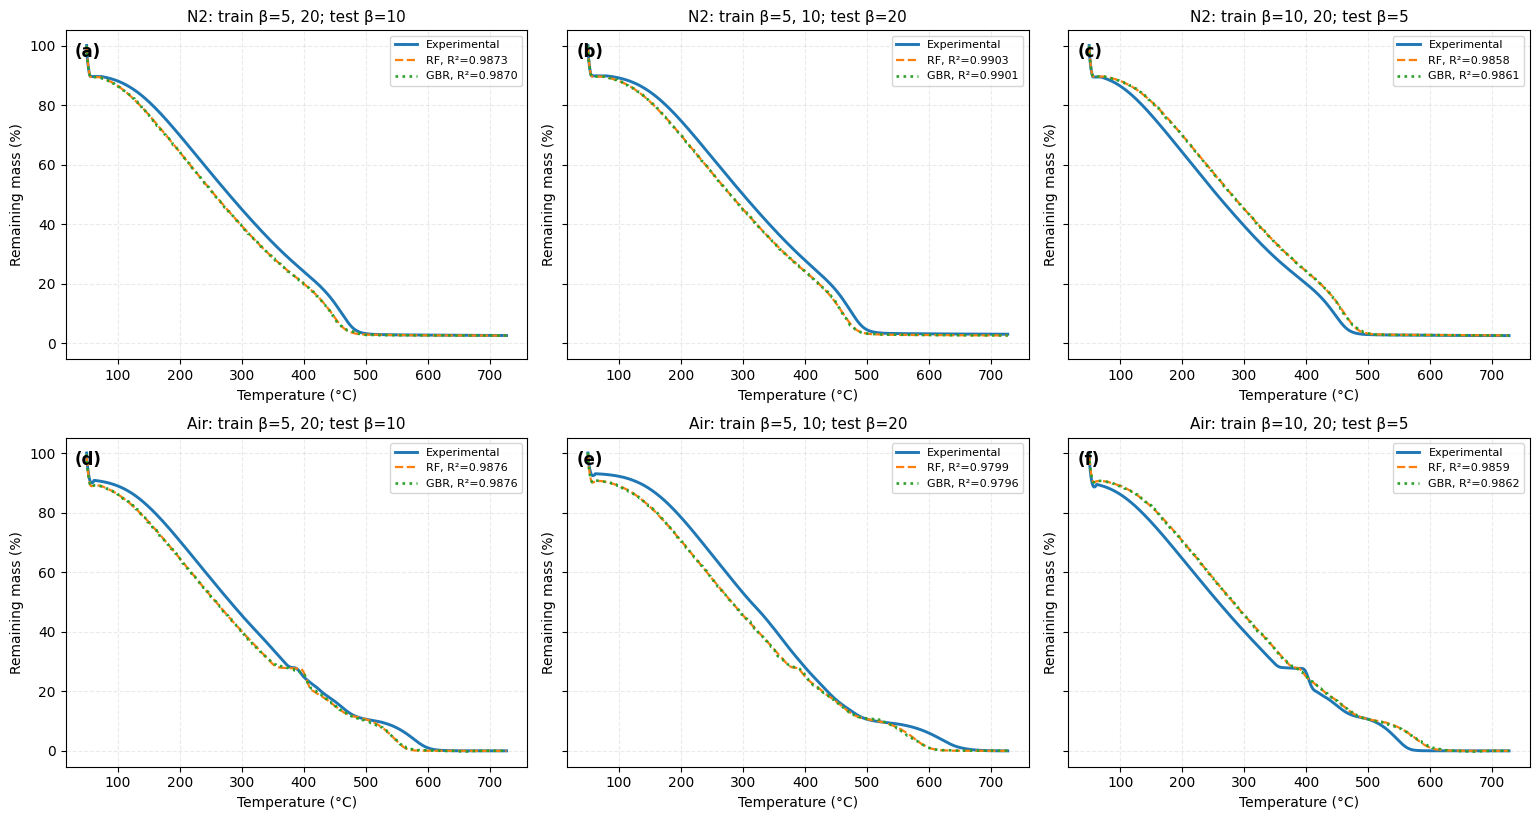

In [6]:
# Publication figure: complete withheld curves, with panel labels.
plt.rcParams.update({'font.size':10,'axes.titlesize':11,'axes.labelsize':10,'legend.fontsize':8})
fig, axes = plt.subplots(2,3,figsize=(15.5,8.3),sharey=True)
for ax, panel, (atm, train_betas, test_beta, holdout_type) in zip(axes.ravel(), list('abcdef'), LORO_CASES):
    test_df, rf_pred = holdout_predictions[(atm,tuple(train_betas),test_beta,'RF')]
    _, gbr_pred = holdout_predictions[(atm,tuple(train_betas),test_beta,'GBR')]
    y = test_df[TARGET].values
    ax.plot(test_df.temp_C,y,lw=2.1,label='Experimental')
    ax.plot(test_df.temp_C,rf_pred,'--',lw=1.6,label=f'RF, R²={r2_score(y,rf_pred):.4f}')
    ax.plot(test_df.temp_C,gbr_pred,':',lw=1.9,label=f'GBR, R²={r2_score(y,gbr_pred):.4f}')
    ax.set_title(f'{atm}: train β={train_betas[0]}, {train_betas[1]}; test β={test_beta}')
    ax.set_xlabel('Temperature (°C)'); ax.set_ylabel('Remaining mass (%)')
    ax.grid(alpha=.25,ls='--'); ax.legend(loc='best')
    ax.text(.02,.96,f'({panel})',transform=ax.transAxes,va='top',fontweight='bold',fontsize=12)
fig.tight_layout()
fig.savefig(os.path.join(OUTDIR,'Figure_Main_Holdout_Predictions.png'),dpi=600,bbox_inches='tight')
plt.show()

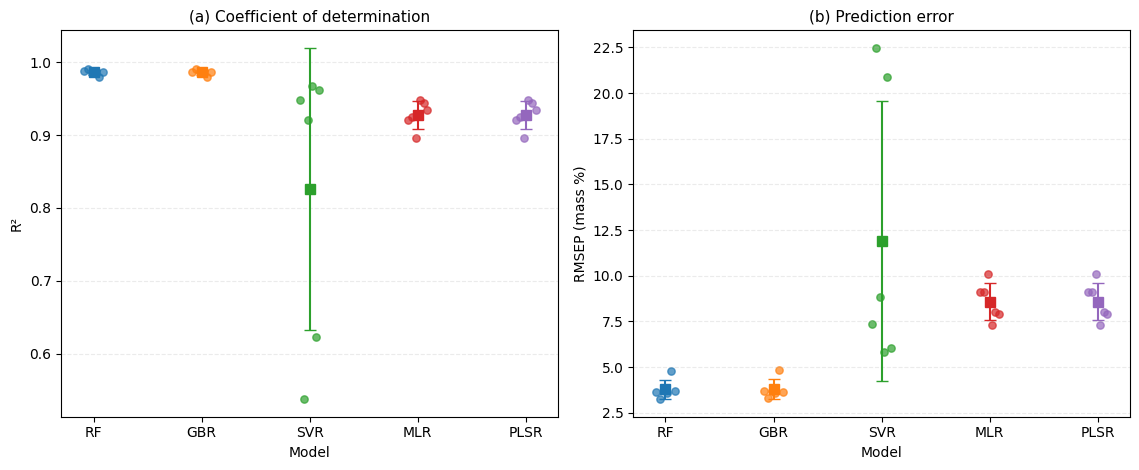

In [7]:
# Publication figure: case-level points and descriptive mean ± SD; no lines between categorical models.
fig, axes = plt.subplots(1,2,figsize=(11.5,4.8))
x = np.arange(len(MODEL_NAMES))
for j, metric in enumerate(['R2','RMSEP']):
    ax = axes[j]
    for i, model in enumerate(MODEL_NAMES):
        vals = holdout_results[holdout_results.Model==model][metric].values
        jitter = np.linspace(-.09,.09,len(vals))
        ax.scatter(np.full(len(vals),i)+jitter,vals,s=28,alpha=.7)
        ax.errorbar(i,np.mean(vals),yerr=np.std(vals,ddof=1),fmt='s',capsize=4,markersize=7)
    ax.set_xticks(x,MODEL_NAMES); ax.grid(axis='y',alpha=.25,ls='--'); ax.set_xlabel('Model')
axes[0].set_ylabel('R²'); axes[0].set_title('(a) Coefficient of determination')
axes[1].set_ylabel('RMSEP (mass %)'); axes[1].set_title('(b) Prediction error')
fig.tight_layout()
fig.savefig(os.path.join(OUTDIR,'Figure_Main_Model_Performance.png'),dpi=500,bbox_inches='tight')
plt.show()

**Tree-model boundary interpretation.** The upper- and lower-bound tests withhold a heating-rate curve outside the two training-rate values. RF and GBR do not continuously extrapolate the numerical heating-rate variable beyond its observed range; they route the boundary value through terminal tree regions. The results therefore demonstrate reconstruction of a withheld boundary-rate curve, not discovery of a continuous physical heating-rate law.

## 5. Temperature-only versus temperature-plus-heating-rate ablation

In [8]:
ablation_rows = []
for atm, train_betas, test_beta, holdout_type in LORO_CASES:
    for feature_name, features in [('T only',['temp_K']),('T + beta',['temp_K','beta'])]:
        _, Xtr, ytr = get_subset(atm,train_betas,features)
        _, Xte, yte = get_subset(atm,[test_beta],features)
        for name in ['RF','GBR']:
            model, scale = make_models(len(features))[name]
            pred = fit_predict(copy.deepcopy(model),Xtr.copy(),ytr,Xte.copy(),scale)
            ablation_rows.append({
                'Atmosphere':atm,'Train_betas':','.join(map(str,train_betas)),
                'Test_beta':test_beta,'Holdout_type':holdout_type,
                'Model':name,'Feature_set':feature_name,**score(yte,pred)
            })
ablation_results = pd.DataFrame(ablation_rows)
ablation_summary = ablation_results.groupby(['Model','Feature_set'])[['R2','RMSEP','MAE']].agg(['mean','std','min','max'])
ablation_summary.columns = ['_'.join(c) for c in ablation_summary.columns]
ablation_summary = ablation_summary.reset_index()
ablation_summary.round(6)

,Model,Feature_set,R2_mean,R2_std,R2_min,R2_max,RMSEP_mean,RMSEP_std,RMSEP_min,RMSEP_max,MAE_mean,MAE_std,MAE_min,MAE_max
0,GBR,T + beta,0.986105,0.003485,0.979650,0.990116,3.785579,0.538059,3.285079,4.841501,2.950363,0.458244,2.610956,3.870449
1,GBR,T only,0.978723,0.016841,0.962849,0.999877,4.036882,2.659491,0.358546,6.541571,3.179482,2.098134,0.301442,5.218375
2,RF,T + beta,0.986126,0.003444,0.979930,0.990271,3.781926,0.529006,3.259218,4.808091,2.943905,0.440925,2.600904,3.824444
3,RF,T only,0.978644,0.016860,0.962475,0.999840,4.061396,2.627496,0.408517,6.501982,3.194166,2.080312,0.321684,5.187476


Temperature alone explains most of the TG variance. Adding β improves mean performance for the upper- and lower-bound holdouts, but it does not improve the intermediate-rate case: for that case, temperature-only RF/GBR predictions are closer to the measured curve. This confirms that the discrete tree treatment of β does not produce uniformly smooth intermediate-rate interpolation.

## 6. MLR-PLSR numerical equivalence audit

In [9]:
wide = holdout_results[holdout_results.Model.isin(['MLR','PLSR'])].pivot_table(
    index=['Atmosphere','Train_betas','Test_beta'], columns='Model', values=['R2','RMSEP','MAE'])
for metric in ['R2','RMSEP','MAE']:
    print(metric, np.max(np.abs(wide[metric]['MLR']-wide[metric]['PLSR'])))

R2 4.440892098500626e-16
RMSEP 2.1316282072803006e-14
MAE 1.509903313490213e-14


## 7. Post-hoc sensitivity checks (descriptive only)

In [10]:
# These analyses are performed after fixing the configurations and are not used to tune the final holdout scores.
RF_N_EST=[10,30,100]
RF_DEPTHS=list(range(1,11))
_, Xtr, ytr = get_subset('N2',[5,20],FEATURES)
_, Xte, yte = get_subset('N2',[10],FEATURES)
rf_rows=[]
for n in RF_N_EST:
    for depth in RF_DEPTHS:
        m=RandomForestRegressor(n_estimators=n,max_depth=depth,random_state=RANDOM_STATE,n_jobs=-1)
        m.fit(Xtr,ytr)
        rf_rows.append({'n_estimators':n,'max_depth':depth,
                        'Train_R2':r2_score(ytr,m.predict(Xtr)),
                        'Test_R2':r2_score(yte,m.predict(Xte))})
rf_sensitivity=pd.DataFrame(rf_rows)
rf_sensitivity.head()

,n_estimators,max_depth,Train_R2,Test_R2
0,10,1,0.830125,0.839097
1,10,2,0.967121,0.978583
2,10,3,0.985835,0.997390
3,10,4,0.997278,0.988114
4,10,5,0.999605,0.988362


In [11]:
GBR_N_EST=[10,30,100]
GBR_DEPTHS=[2,4,6]
gbr_rows=[]
for depth in GBR_DEPTHS:
    for n in GBR_N_EST:
        m=GradientBoostingRegressor(n_estimators=n,max_depth=depth,learning_rate=0.1,random_state=RANDOM_STATE)
        m.fit(Xtr,ytr)
        gbr_rows.append({'max_depth':depth,'n_estimators':n,
                         'Train_R2':r2_score(ytr,m.predict(Xtr)),
                         'Test_R2':r2_score(yte,m.predict(Xte))})
gbr_sensitivity=pd.DataFrame(gbr_rows)
gbr_sensitivity

,max_depth,n_estimators,Train_R2,Test_R2
0,2,10,0.855874,0.862590
1,2,30,0.991350,0.988978
2,2,100,0.998518,0.990264
3,4,10,0.876015,0.856471
4,4,30,0.997988,0.983568
5,4,100,0.999973,0.987028
6,6,10,0.878268,0.856728
7,6,30,0.998194,0.983407
8,6,100,1.000000,0.987060


## 8. Export final numerical results

In [12]:
exports = {
    'Random_Benchmark.csv': random_benchmark,
    'Holdout_Results.csv': holdout_results,
    'Holdout_Summary.csv': holdout_summary,
    'Ablation_Results.csv': ablation_results,
    'Ablation_Summary.csv': ablation_summary,
    'RF_Sensitivity_Posthoc_Reduced.csv': rf_sensitivity,
    'GBR_Sensitivity_Posthoc_Reduced.csv': gbr_sensitivity,
}
for filename, table in exports.items():
    table.to_csv(os.path.join(OUTDIR,filename),index=False)
print('Exported',len(exports),'tables to',OUTDIR)

Exported 7 tables to Arab_Light_TGA_ML_REVISED_outputs


## Final interpretation

1. RF and GBR provide essentially equivalent complete-curve holdout performance.
2. The random row split is an optimistic reconstruction benchmark.
3. Boundary-rate holdouts should not be presented as proof of continuous tree-model extrapolation.
4. Temperature is the dominant predictor; adding heating rate improves mean boundary-holdout accuracy but does not uniformly improve the intermediate-rate holdout.
5. The fixed SVR configuration is much more condition-sensitive than the tree ensembles.
6. MLR and PLSR are numerically equivalent in this two-predictor/two-component implementation.
7. The supplied dataset contains six measured curves from one Arab Light sample and no replicate curves, so uncertainty and generalization claims must remain limited.